# 03 — Optimización por Colonia de Hormigas (ACO)
**Metaheurísticas — Notebook 3 de 5**

La Optimización por Colonia de Hormigas (Marco **Dorigo, 1992**) es una metaheurística
**poblacional/de enjambre** inspirada en las hormigas reales. Las hormigas depositan
**feromonas** en sus caminos; los más cortos se refuerzan más rápido. Esta comunicación
indirecta a través del entorno se llama **estigmergia**.

## ¿Qué aprenderás?
1. Qué es la **estigmergia** y cómo se modela con feromonas.
2. La regla de construcción probabilística: $\tau$, $\eta$, $\alpha$, $\beta$.
3. El ciclo de **evaporación + depósito**.
4. Implementación para:
   - **Ejemplo 1 — Coloración de Grafos** (20 nodos).
   - **Ejemplo 2 — Planificación de Trabajos en Máquinas** (minimizar makespan).


## 1. La analogía biológica

Las hormigas son individualmente simples pero colectivamente inteligentes:
1. Una hormiga recorre aleatoriamente el entorno buscando comida.
2. Al regresar, deposita feromona proporcional a qué tan bueno fue el camino.
3. Las feromonas más concentradas atraen a más hormigas.
4. Los buenos caminos se refuerzan acumulativamente.
5. La **evaporación** elimina feromonas antiguas para adaptarse a cambios.

## 2. Regla de construcción probabilística

Una hormiga en el estado $i$ elige el siguiente estado $j$ con probabilidad:

$$p_{ij} = \frac{\tau_{ij}^{\alpha} \cdot \eta_{ij}^{\beta}}{\sum_{l \in \text{permitidos}} \tau_{il}^{\alpha} \cdot \eta_{il}^{\beta}}$$

- $\tau_{ij}$: **feromona** — memoria colectiva aprendida.
- $\eta_{ij}$: **heurística** — conocimiento específico del problema (ej. $1/d_{ij}$).
- $\alpha$: peso de feromona. Alto $\to$ sigue a la mayoría (riesgo de convergencia prematura).
- $\beta$: peso de heurística. Alto $\to$ comportamiento más greedy.

## 3. Actualización de feromonas

$$\tau_{ij} \leftarrow (1-\rho)\,\tau_{ij} + \sum_{k} \Delta\tau_{ij}^{k}$$

- $(1-\rho)$: **evaporación** — olvido selectivo. $\rho$ alta $\to$ olvida rápido $\to$ más exploración.
- $\Delta\tau_{ij}^k = Q/L_k$ si la hormiga $k$ usó $(i,j)$; 0 si no.
  Las soluciones **mejores** (menor $L_k$) depositan **más** feromona ($1/L_k$ crece cuando $L_k$ baja).

```
funcion ACO():
    inicializar tau_ij = tau_0 (constante pequeña, uniforme)
    repetir n_iter veces:
        para cada hormiga k:
            construir solucion S_k usando p_ij        <- construccion probabilistica
            calcular costo L_k
        evaporar: tau <- (1-rho)*tau
        depositar: tau_ij += Q/L_k  para cada hormiga k que uso (i,j)
        actualizar el mejor global
    retornar mejor solucion
```


In [1]:
%matplotlib inline
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath("common.py")))
import numpy as np
import matplotlib.pyplot as plt
import common

G = common.crear_grafo(n=20, prob=0.35, seed=42)
pos = common.posiciones_grafo(G, seed=42)
n = G.number_of_nodes()
adj = {v: list(G.neighbors(v)) for v in range(n)}
print(f"Grafo: {n} nodos, {G.number_of_edges()} aristas")

s_greedy = common.coloracion_greedy(G, seed=0)
print(f"Coloracion greedy (referencia): {common.num_colores(s_greedy)} colores")


Grafo: 20 nodos, 76 aristas
Coloracion greedy (referencia): 5 colores


In [2]:
def aco_coloracion(G, n_hormigas=30, n_iter=100,
                   alpha=1.0, beta=2.0, rho=0.3, Q=1.0, seed=0):
    """
    ACO para Coloracion de Grafos.

    tau[v][c] = deseo colectivo de asignar color c al nodo v.
    eta[v][c] = 1.0 si c no conflictua con vecinos ya coloreados, 1e-6 si sí.

    Construccion (por hormiga):
      - Ordenar nodos por saturacion decreciente (DSATUR-like).
      - Para cada nodo v, elegir color c segun tau[v][c]^alpha * eta[v][c]^beta.
      - Si no hay color valido, abrir un nuevo color.

    Actualizacion: solo hormigas con coloracion valida depositan.
    Deposito = Q / k_hormiga  (menos colores -> mas feromona).
    """
    rng = np.random.default_rng(seed)
    k_max = n   # numero maximo de colores posibles
    tau = np.ones((n, k_max)) * 0.1   # feromonas iniciales uniformes

    mejor_sol = common.coloracion_greedy(G, seed=0)
    mejor_k   = common.num_colores(mejor_sol)
    historia = []

    for _iter in range(n_iter):
        todas_sols, todos_k = [], []

        for _h in range(n_hormigas):
            col = [-1] * n

            for _paso in range(n):
                # Nodo con mayor saturacion entre los no coloreados
                sin_col = [v for v in range(n) if col[v] < 0]
                if not sin_col:
                    break
                v = max(sin_col,
                        key=lambda x: (len({col[u] for u in adj[x] if col[u] >= 0}),
                                        G.degree(x)))

                vec_col = {col[u] for u in adj[v] if col[u] >= 0}
                k_act = max((max(col) + 1 if max(col) >= 0 else 0), 0)

                cands = [c for c in range(k_act) if c not in vec_col]
                cands.append(k_act)   # nuevo color

                pesos = np.array([
                    (tau[v][c] ** alpha) *
                    (1.0 if c not in vec_col else 1e-6) ** beta
                    for c in cands
                ])
                s = pesos.sum()
                probs = pesos / s if s > 0 else np.ones(len(cands)) / len(cands)
                col[v] = cands[rng.choice(len(cands), p=probs)]

            k_h = common.num_colores(col)
            todas_sols.append(col); todos_k.append(k_h)
            if common.coloracion_valida(col, G) and k_h < mejor_k:
                mejor_sol = list(col); mejor_k = k_h

        # Evaporar
        tau *= (1.0 - rho)
        tau = np.maximum(tau, 1e-6)

        # Depositar (solo soluciones validas)
        for col, k_h in zip(todas_sols, todos_k):
            if common.coloracion_valida(col, G):
                dep = Q / k_h
                for v in range(n):
                    c = col[v]
                    if c < k_max:
                        tau[v][c] += dep

        historia.append(mejor_k)

    return mejor_sol, mejor_k, historia, tau

sol_aco, k_aco, hist_aco, tau_f = aco_coloracion(G, seed=1)
print(f"ACO resultado:")
print(f"  Colores: {k_aco}, Valida: {common.coloracion_valida(sol_aco, G)}")
print(f"\nGreedy: {common.num_colores(s_greedy)} -> ACO: {k_aco} colores")


ACO resultado:
  Colores: 5, Valida: True

Greedy: 5 -> ACO: 5 colores


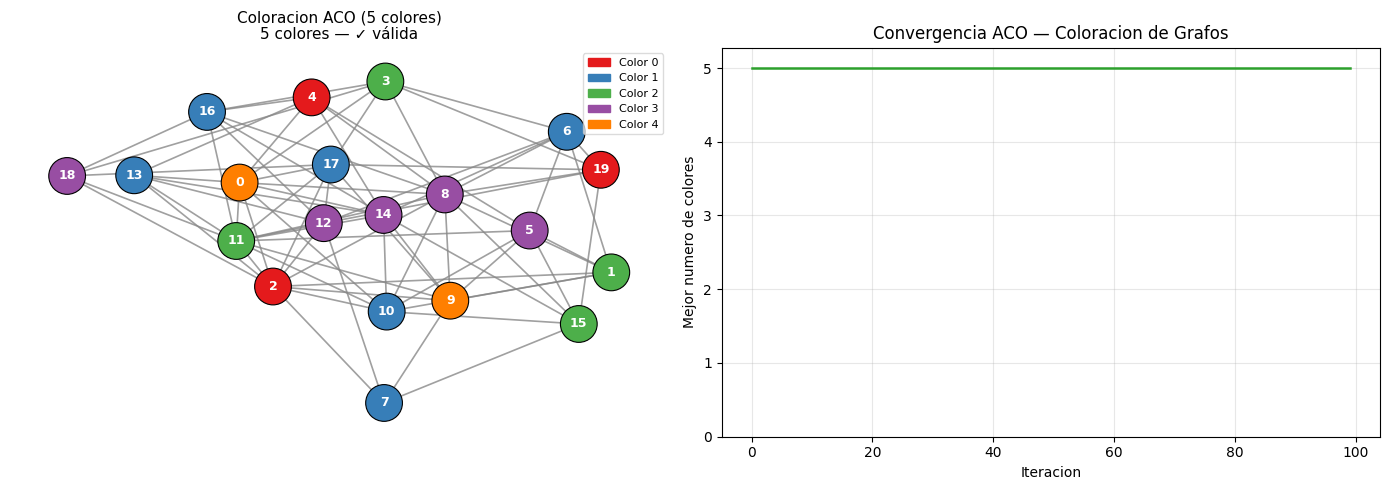

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
common.plot_grafo(G, sol_aco, f"Coloracion ACO ({k_aco} colores)", ax=axes[0], pos=pos)
axes[1].plot(hist_aco, color="tab:green", lw=1.8)
axes[1].set_title("Convergencia ACO — Coloracion de Grafos")
axes[1].set_xlabel("Iteracion"); axes[1].set_ylabel("Mejor numero de colores")
axes[1].set_ylim(bottom=0); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


### Mapa de feromonas

Después de la convergencia, $\tau[v][c]$ concentra el conocimiento colectivo:
valores altos indican qué color es más "natural" para cada nodo.


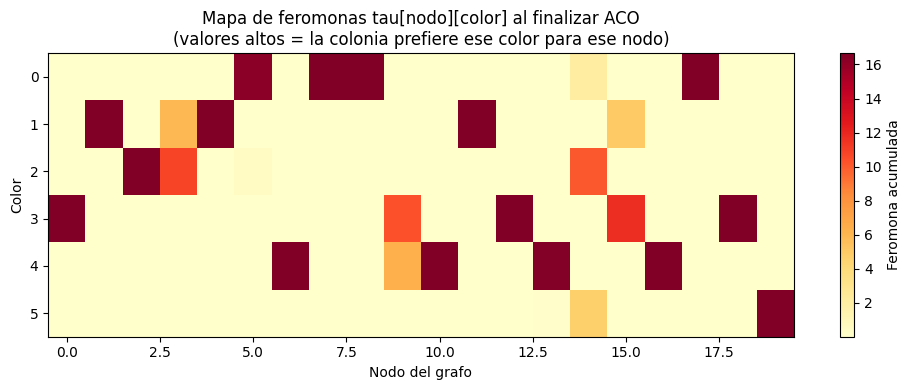

Las columnas brillantes muestran el color elegido por el colectivo para cada nodo.


In [4]:
k_vis = k_aco + 1
tau_vis = tau_f[:, :k_vis]
fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(tau_vis.T, aspect="auto", cmap="YlOrRd")
ax.set_xlabel("Nodo del grafo"); ax.set_ylabel("Color")
ax.set_yticks(range(k_vis))
ax.set_title("Mapa de feromonas tau[nodo][color] al finalizar ACO\n"
             "(valores altos = la colonia prefiere ese color para ese nodo)")
plt.colorbar(im, ax=ax, label="Feromona acumulada")
plt.tight_layout(); plt.show()
print("Las columnas brillantes muestran el color elegido por el colectivo para cada nodo.")


## Ejemplo 2 — Planificación de Trabajos en Máquinas (Job Scheduling)

Dados $n$ trabajos con tiempos $p_i$ y $m$ máquinas paralelas idénticas, asignar
cada trabajo a exactamente una máquina minimizando el **makespan** (carga máxima):

$$\min \; \max_{j=1}^{m} \sum_{i \in M_j} p_i$$

NP-difícil para $m \geq 2$. Aplicaciones: manufactura, computación en la nube.

**ACO para Scheduling:**
- $\tau[i][j]$: deseabilidad de asignar trabajo $i$ a máquina $j$.
- $\eta[i][j] = 1/(1 + \text{carga}[j])$: prefiere la máquina con menos carga.
- Una hormiga asigna los $n$ trabajos en orden aleatorio, eligiendo máquina probabilísticamente.


In [5]:
def aco_scheduling(n_trabajos=20, n_maquinas=4, n_hormigas=25,
                    n_iter=80, alpha=1.0, beta=3.0, rho=0.4, Q=1.0, seed=0):
    """
    ACO para minimizar el makespan en maquinas paralelas.

    asignacion[i] = j significa que el trabajo i va a la maquina j.
    Makespan = max(carga de cada maquina).
    """
    rng = np.random.default_rng(seed)
    rng_inst = np.random.default_rng(99)
    tiempos = rng_inst.integers(1, 15, size=n_trabajos)
    print(f"Tiempos de trabajos: {tiempos}")
    print(f"Suma total: {tiempos.sum()}, Cota inferior ideal: {tiempos.sum()/n_maquinas:.1f}")

    tau = np.ones((n_trabajos, n_maquinas)) * 0.5
    mejor_asign = None; mejor_ms = np.inf; historia = []

    for _ in range(n_iter):
        asigns = []; mss = []
        for _k in range(n_hormigas):
            orden = list(rng.permutation(n_trabajos))
            cargas = np.zeros(n_maquinas)
            asign = np.zeros(n_trabajos, dtype=int)
            for i in orden:
                eta = 1.0 / (1.0 + cargas)
                pesos = (tau[i] ** alpha) * (eta ** beta)
                probs = pesos / pesos.sum()
                j = int(rng.choice(n_maquinas, p=probs))
                asign[i] = j; cargas[j] += tiempos[i]
            mk = int(cargas.max())
            asigns.append(asign); mss.append(mk)
            if mk < mejor_ms:
                mejor_ms = mk; mejor_asign = asign.copy()

        tau *= (1.0 - rho); tau = np.maximum(tau, 1e-6)
        for asign, mk in zip(asigns, mss):
            for i in range(n_trabajos):
                tau[i][asign[i]] += Q / mk
        historia.append(mejor_ms)

    return mejor_asign, mejor_ms, historia, tiempos

asign, makespan, hist_sched, tiempos = aco_scheduling(seed=5)
print(f"\nMakespan ACO: {makespan}")
n_maq = 4
for j in range(n_maq):
    trab_j = np.where(asign == j)[0]
    print(f"  Maquina {j}: trabajos {list(trab_j)}, tiempos {tiempos[trab_j].tolist()}, "
          f"carga={tiempos[trab_j].sum()}")


Tiempos de trabajos: [14  8 11  8  3  8 14 14 14  9  5  8 10  5 14  8  5  7  2  9]
Suma total: 176, Cota inferior ideal: 44.0



Makespan ACO: 44
  Maquina 0: trabajos [np.int64(0), np.int64(3), np.int64(6), np.int64(11)], tiempos [14, 8, 14, 8], carga=44
  Maquina 1: trabajos [np.int64(4), np.int64(5), np.int64(9), np.int64(13), np.int64(14), np.int64(16)], tiempos [3, 8, 9, 5, 14, 5], carga=44
  Maquina 2: trabajos [np.int64(7), np.int64(8), np.int64(10), np.int64(18), np.int64(19)], tiempos [14, 14, 5, 2, 9], carga=44
  Maquina 3: trabajos [np.int64(1), np.int64(2), np.int64(12), np.int64(15), np.int64(17)], tiempos [8, 11, 10, 8, 7], carga=44


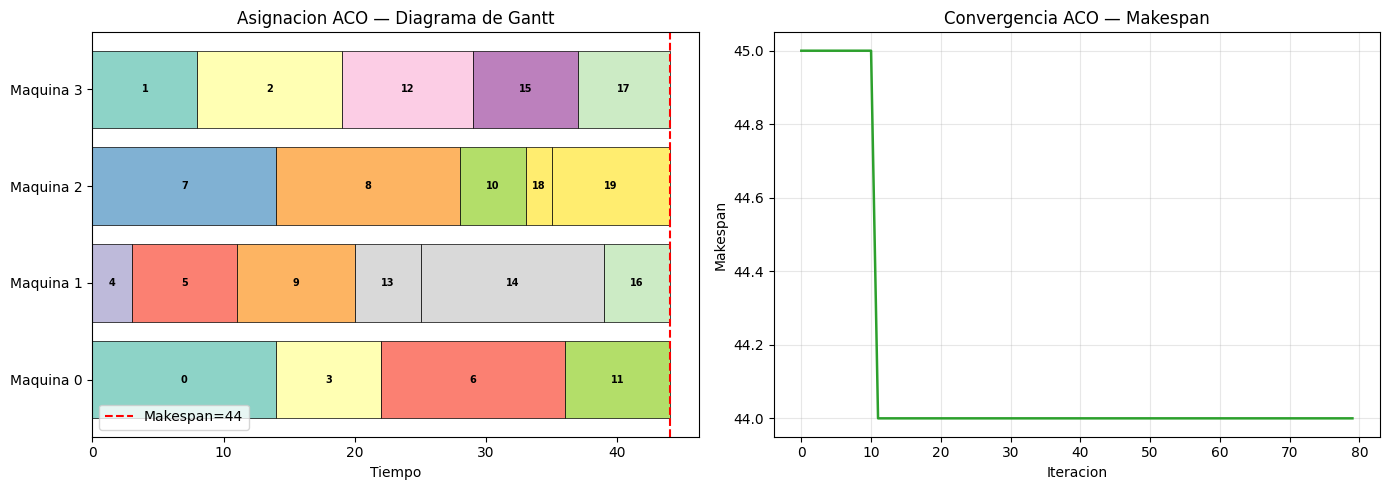

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
n_maq = 4
colores_gantt = plt.cm.Set3(np.linspace(0, 1, len(tiempos)))
posiciones = [0] * n_maq
for i in range(len(tiempos)):
    j = asign[i]
    axes[0].barh(j, tiempos[i], left=posiciones[j], color=colores_gantt[i],
                 edgecolor="black", linewidth=0.5)
    axes[0].text(posiciones[j]+tiempos[i]/2, j, str(i),
                 ha="center", va="center", fontsize=7, fontweight="bold")
    posiciones[j] += tiempos[i]
axes[0].axvline(makespan, color="red", linestyle="--", lw=1.5, label=f"Makespan={makespan}")
axes[0].set_yticks(range(n_maq))
axes[0].set_yticklabels([f"Maquina {j}" for j in range(n_maq)])
axes[0].set_xlabel("Tiempo"); axes[0].set_title("Asignacion ACO — Diagrama de Gantt")
axes[0].legend()
axes[1].plot(hist_sched, color="tab:green", lw=1.8)
axes[1].set_title("Convergencia ACO — Makespan")
axes[1].set_xlabel("Iteracion"); axes[1].set_ylabel("Makespan")
axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## 3. Parámetros, variantes y preguntas frecuentes

| Parámetro | Efecto si alto | Efecto si bajo |
|---|---|---|
| $\alpha$ | Sigue a la mayoría; convergencia prematura | Ignora experiencia colectiva |
| $\beta$ | Greedy (bueno al inicio) | Sin guía heurística |
| $\rho$ | Olvida rápido; más exploración | Recuerda mucho; convergencia prematura |
| $m$ (hormigas) | Mejor muestreo, más costoso | Muestreo pobre |

**Variantes:** Ant System (original) < Ant Colony System (ACS) < MAX-MIN Ant System (MMAS).
MMAS limita $\tau \in [\tau_{\min}, \tau_{\max}]$ y suele dar los mejores resultados.

**¿Qué es la estigmergia?**
Comunicación indirecta a través del entorno. Las hormigas no se hablan entre sí;
la feromona en el suelo es el "mensaje" persistente que todos leen y modifican.

**¿Por qué $\Delta\tau = Q/L_k$ y no $Q \cdot L_k$?**
Queremos que las mejores soluciones (menor $L_k$) depositen más feromona. Como
$L_k$ es el costo (a minimizar), su inversa $1/L_k$ crece cuando el costo baja.

**¿Qué pasa si $\rho = 0$ (sin evaporación)?**
La feromona solo aumenta. Los primeros caminos monopolizan el refuerzo y la colonia
converge prematuramente a una solución posiblemente mala.

## Ejercicios
1. Implementa **elitismo ACO**: la mejor solución global recibe depósito extra cada iteración.
2. Implementa **MMAS**: limita $\tau \in [\tau_{\min}, \tau_{\max}]$.
3. Varía $\beta \in \{0, 1, 2, 4, 8\}$ y grafica el resultado final en coloración.
4. Para scheduling, compara ACO con la heurística **LPT** (asignar el trabajo más largo primero).

## Referencias
- Dorigo (1992), tesis doctoral; Dorigo, Maniezzo & Colorni (1996), *Ant System*.
- Dorigo & Stützle, *Ant Colony Optimization* (2004).
